In [1]:
# imports for the dataset and building our neural network
import tensorflow as tf
from tensorflow import keras
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
# loading the dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [3]:
len(X_train)

50000

In [4]:
len(X_test)

10000

In [5]:
X_train.shape

(50000, 32, 32, 3)

In [6]:
X_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [7]:
X_train[0].shape

(32, 32, 3)

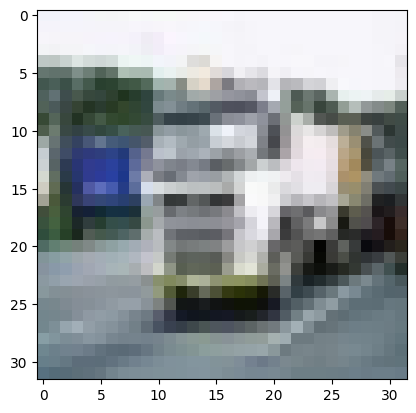

In [8]:
plt.imshow(X_train[1000]) #RGB---BGR

In [9]:
y_train[0]

array([6], dtype=uint8)

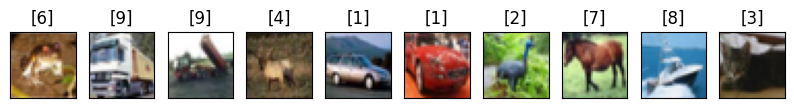

In [10]:
# Display some images
fig, axes = plt.subplots(ncols=10, sharex=False, 
    sharey=True, figsize=(10, 4))
for i in range(10):
    axes[i].set_title(y_train[i])
    axes[i].imshow(X_train[i], cmap='gray')
    axes[i].get_xaxis().set_visible(False)
    axes[i].get_yaxis().set_visible(False)
plt.show()
#classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [11]:
X_train.shape[0]

50000

In [12]:
X_train[0].shape

(32, 32, 3)

In [13]:
X_train.shape[0]

50000

In [14]:
X_train[0].dtype

dtype('uint8')

In [15]:
X_train.shape

(50000, 32, 32, 3)

In [19]:
# normalizing the data to help with the training
X_train =X_train/ 255
X_test =X_test/ 255

In [20]:
# building a linear stack of layers with the sequential model
model = Sequential()

In [21]:

# convolutional layer
conv_1=Conv2D(filters=32, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu', input_shape=(32, 32, 3))
model.add(conv_1)


c:\Users\nilay\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
#task: add more covolution layers and train the model

# convolutional layer
conv2=Conv2D(filters=64, kernel_size=3, strides=1, padding='valid', activation='relu')
model.add(conv2)

mp2=MaxPool2D(pool_size=(2,2))
model.add(mp2)


In [23]:
# flatten output of conv
model.add(Flatten())

In [24]:
# hidden layer
model.add(Dense(100, activation='relu'))
model.add(Dense(50, activation='relu'))
# output layer
model.add(Dense(10, activation='softmax'))

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     1,440,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,465,052 (5.59 MB)

 Trainable params: 1,465,052 (5.59 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# compiling the sequential model
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

# training the model for 10 epochs
model.fit(X_train, y_train, batch_size=128, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 142ms/step - accuracy: 0.3489 - loss: 1.7774 - val_accuracy: 0.5695 - val_loss: 1.2299
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 49s 126ms/step - accuracy: 0.5961 - loss: 1.1410 - val_accuracy: 0.6314 - val_loss: 1.0668
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 115ms/step - accuracy: 0.6680 - loss: 0.9532 - val_accuracy: 0.6633 - val_loss: 0.9885
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - accuracy: 0.7087 - loss: 0.8325 - val_accuracy: 0.6580 - val_loss: 1.0059
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.7443 - loss: 0.7380 - val_accuracy: 0.6804 - val_loss: 0.9370
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.7747 - loss: 0.6492 - val_accuracy: 0.6825 - val_loss: 0.9366
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 116ms/step - accuracy: 0.7952 - loss: 0.5841 - val_accuracy: 0.6842 - val_loss: 0.9391
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 119ms/step - accuracy: 0.8259 - loss: 0

In [39]:
model.history.history

{'loss': [1.7141858339309692,
  1.290534257888794,
  1.1549263000488281,
  1.065773844718933,
  0.9947389960289001,
  0.9110465049743652,
  0.8421573638916016,
  0.7742999196052551,
  0.7046595215797424,
  0.6423268914222717],
 'accuracy': [0.3982200026512146,
  0.5437600016593933,
  0.5952200293540955,
  0.6266800165176392,
  0.652400016784668,
  0.6816800236701965,
  0.7031800150871277,
  0.7308400273323059,
  0.7539399862289429,
  0.777180016040802],
 'val_loss': [1.3930344581604004,
  1.2629170417785645,
  1.1952006816864014,
  1.1863104104995728,
  1.1562738418579102,
  1.1479785442352295,
  1.1931557655334473,
  1.1593637466430664,
  1.134281873703003,
  1.1902285814285278],
 'val_accuracy': [0.5023000240325928,
  0.551800012588501,
  0.578000009059906,
  0.5795999765396118,
  0.5985000133514404,
  0.6046000123023987,
  0.592199981212616,
  0.6093999743461609,
  0.6157000064849854,
  0.6187000274658203]}

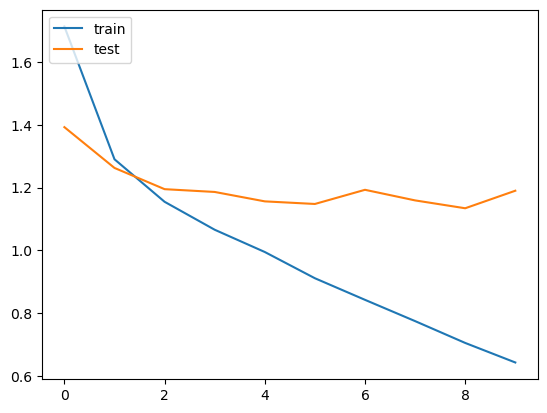

In [40]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.legend(['train', 'test'], loc='upper left')

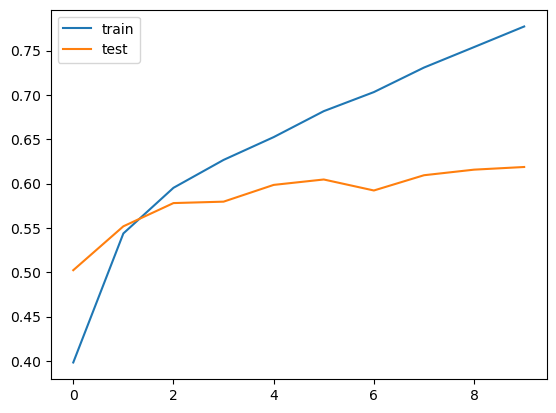

In [41]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.legend(['train', 'test'], loc='upper left')

In [45]:
import numpy as np
import tensorflow as tf
# Predict the values from the validation dataset
y_pred = model.predict(X_test)
# Convert predictions classes to one hot vectors 
y_pred_classes = np.argmax(y_pred,axis = 1) 

# compute the confusion matrix
confusion_mtx = tf.math.confusion_matrix(y_test, y_pred_classes)
confusion_mtx

313/313 [==============================] - 2s 6ms/step


<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[692,  41,  62,  40,  14,   3,   8,  13,  93,  34],
       [ 28, 794,  11,  18,   4,   4,   8,   6,  38,  89],
       [ 79,  10, 474, 116, 127,  62,  63,  44,  14,  11],
       [ 25,  24,  79, 551,  55, 125,  75,  33,  16,  17],
       [ 36,  13, 105, 109, 558,  31,  66,  66,  12,   4],
       [ 20,  15,  76, 306,  46, 440,  30,  50,  10,   7],
       [  9,  26,  57,  93,  65,  26, 690,  12,   8,  14],
       [ 22,  15,  59,  87,  62,  61,  11, 652,   5,  26],
       [ 97,  82,  17,  26,   9,  11,   5,   3, 719,  31],
       [ 41, 183,  13,  39,   9,   5,  14,  25,  54, 617]])>

[[Text(0.5, 0, 'airplane'),
  Text(1.5, 0, 'automobile'),
  Text(2.5, 0, 'bird'),
  Text(3.5, 0, 'cat'),
  Text(4.5, 0, 'deer'),
  Text(5.5, 0, 'dog'),
  Text(6.5, 0, 'frog'),
  Text(7.5, 0, 'horse'),
  Text(8.5, 0, 'ship'),
  Text(9.5, 0, 'truck')],
 [Text(0, 0.5, 'airplane'),
  Text(0, 1.5, 'automobile'),
  Text(0, 2.5, 'bird'),
  Text(0, 3.5, 'cat'),
  Text(0, 4.5, 'deer'),
  Text(0, 5.5, 'dog'),
  Text(0, 6.5, 'frog'),
  Text(0, 7.5, 'horse'),
  Text(0, 8.5, 'ship'),
  Text(0, 9.5, 'truck')]]

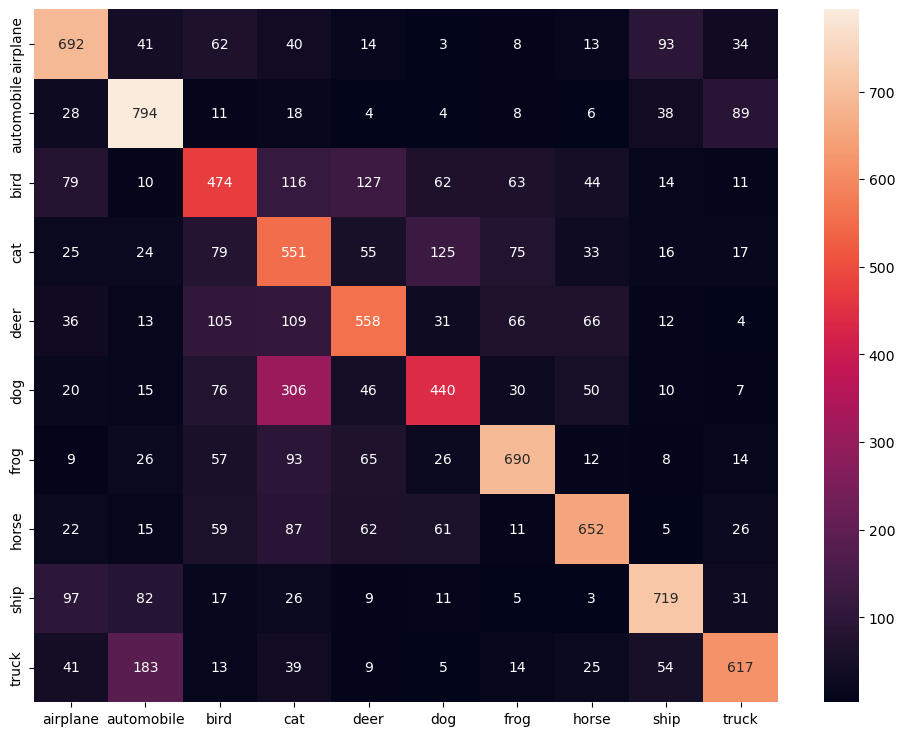

In [46]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(12, 9))
c = sns.heatmap(confusion_mtx, annot=True, fmt='g')
c.set(xticklabels=classes, yticklabels=classes)

In [ ]:
####-------Train CNN using data-augmentation--------#####
train_datagen = ImageDataGenerator(rescale=1./255, rotation=40, width_shift=0.2, height_shift=0.2, shear=0.2, zoom=0.2, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow(X_train,batch_size=32, class_mode='binary')
validation_generator = test_datagen.flow_from_directory(validation_dir, target_size=(150, 150), batch_size=32, class_mode='binary')
history = model.fit_generator(train_generator, steps_per_epoch=100, epochs=100, validation_data=validation_generator, validation_steps=50)